In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df = pd.read_csv("SupportVectorRegression_insurance.csv")

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Data Cleaning

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Feature Engineering

In [7]:
Male = pd.get_dummies(df['sex'], drop_first= True)
df = pd.concat([df,Male], axis=1)
df.head()

,age,sex,bmi,children,smoker,region,charges,male
0,19,female,27.900,0,yes,southwest,16884.92400,0
1,18,male,33.770,1,no,southeast,1725.55230,1
2,28,male,33.000,3,no,southeast,4449.46200,1
3,33,male,22.705,0,no,northwest,21984.47061,1
4,32,male,28.880,0,no,northwest,3866.85520,1


In [8]:
Smoker = pd.get_dummies(df['smoker'], drop_first=True)
df = pd.concat([df,Smoker],axis=1)
df.head()

,age,sex,bmi,children,smoker,region,charges,male,yes
0,19,female,27.900,0,yes,southwest,16884.92400,0,1
1,18,male,33.770,1,no,southeast,1725.55230,1,0
2,28,male,33.000,3,no,southeast,4449.46200,1,0
3,33,male,22.705,0,no,northwest,21984.47061,1,0
4,32,male,28.880,0,no,northwest,3866.85520,1,0


In [9]:
df= df.rename(columns={'yes':'Smoker'})
df.head()

,age,sex,bmi,children,smoker,region,charges,male,Smoker
0,19,female,27.900,0,yes,southwest,16884.92400,0,1
1,18,male,33.770,1,no,southeast,1725.55230,1,0
2,28,male,33.000,3,no,southeast,4449.46200,1,0
3,33,male,22.705,0,no,northwest,21984.47061,1,0
4,32,male,28.880,0,no,northwest,3866.85520,1,0


In [10]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [11]:
Region = pd.get_dummies(df['region'],drop_first=True)
df = pd.concat([df,Region],axis=1)
df.head()

,age,sex,bmi,children,smoker,region,charges,male,Smoker,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,0,1,0,0,1
1,18,male,33.770,1,no,southeast,1725.55230,1,0,0,1,0
2,28,male,33.000,3,no,southeast,4449.46200,1,0,0,1,0
3,33,male,22.705,0,no,northwest,21984.47061,1,0,1,0,0
4,32,male,28.880,0,no,northwest,3866.85520,1,0,1,0,0


## Exploratory Analysis

Distribution of Sex parameter

male      676
female    662
Name: sex, dtype: int64

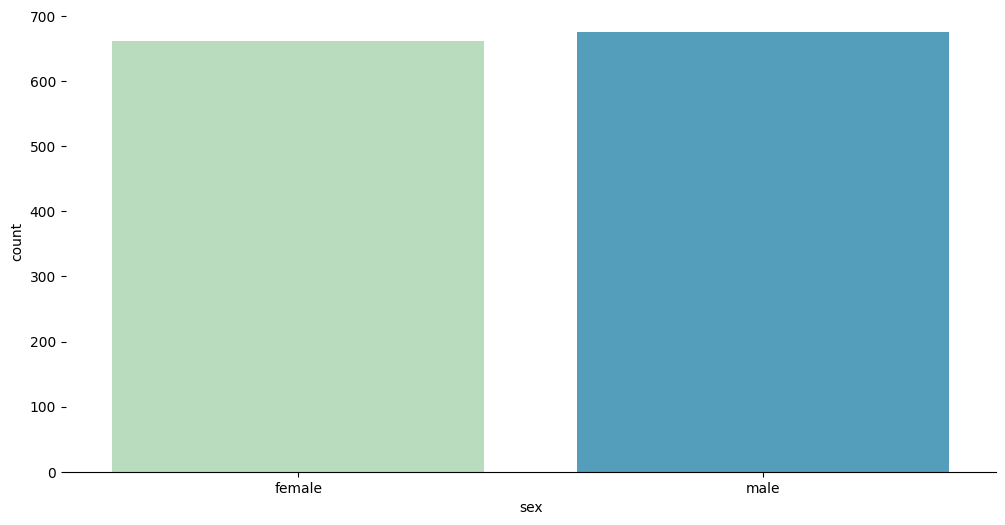

In [12]:
plt.figure(figsize=(12,6))
sns.countplot(x="sex", data=df, palette= 'GnBu')
sns.despine(left=True)

df['sex'].value_counts()

Relationship of Smoking and Gender to Charges

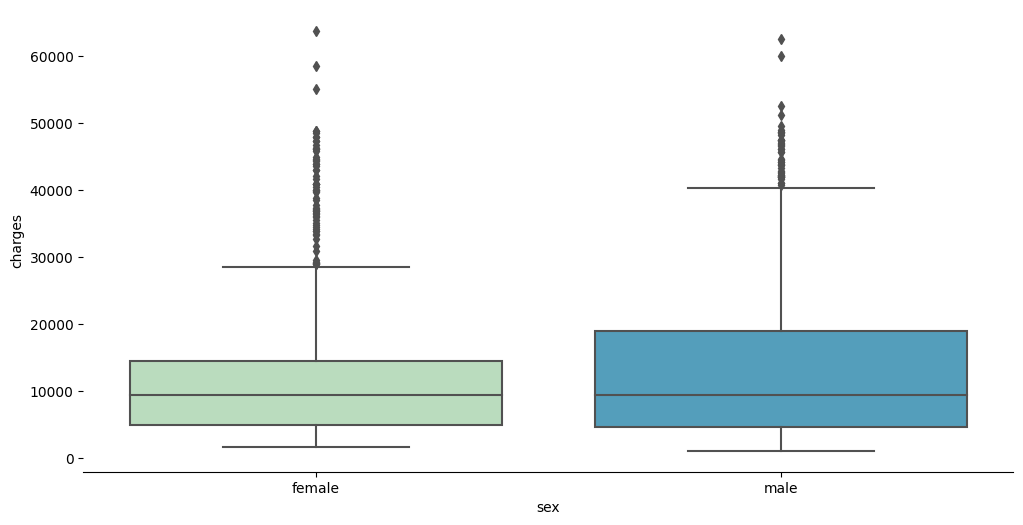

In [13]:
plt.figure(figsize=(12,6))
sns.boxplot(x="sex", y='charges',data=df, palette= 'GnBu')
sns.despine(left=True)

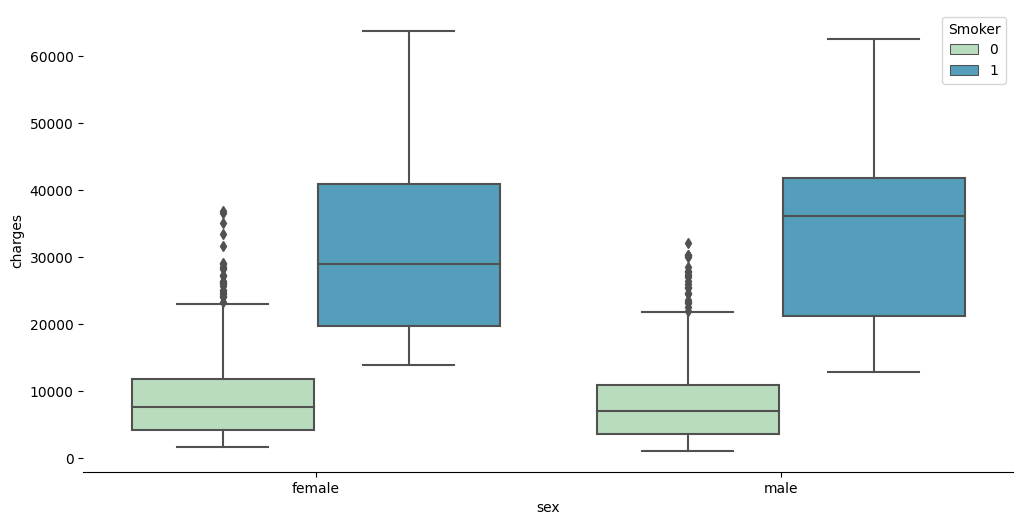

In [14]:
plt.figure(figsize=(12,6))
sns.boxplot(x="sex", y='charges',data=df, palette= 'GnBu', hue='Smoker')
sns.despine(left=True)

<Axes: xlabel='age', ylabel='charges'>

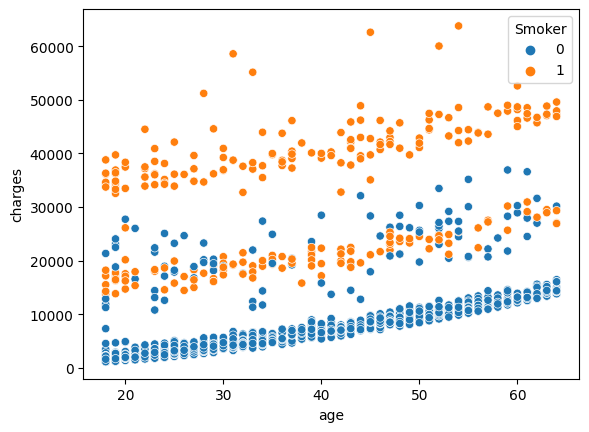

In [15]:
sns.scatterplot(x='age', y='charges',hue='Smoker', data=df)

<Axes: xlabel='bmi', ylabel='charges'>

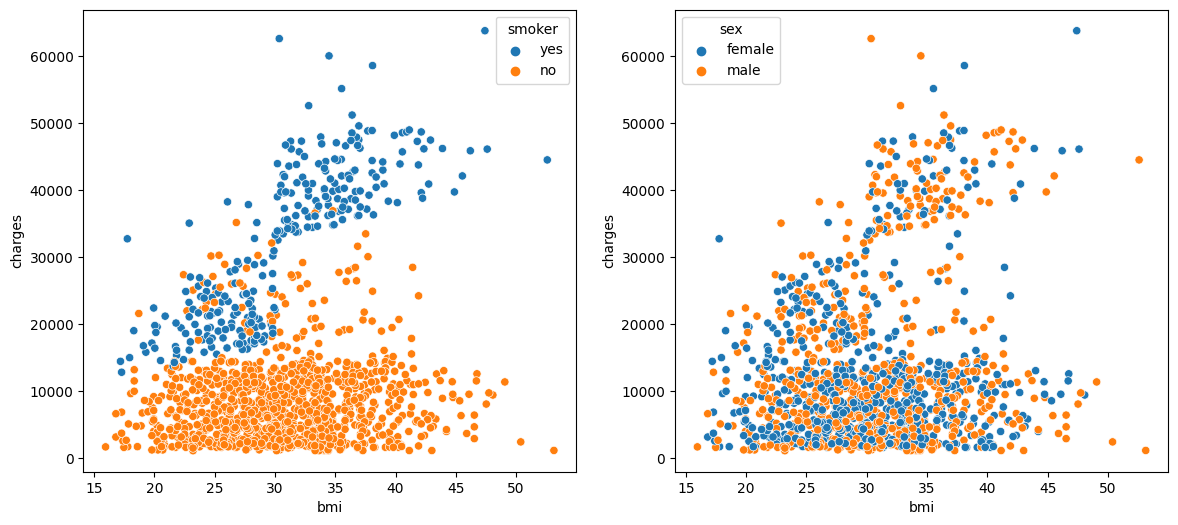

In [16]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize = (14,6))
sns.scatterplot(x='bmi',y='charges',hue='smoker',data=df, ax = ax[0])
sns.scatterplot(x='bmi',y='charges',hue='sex',data=df, ax=ax[1])

In [17]:
df.head()

,age,sex,bmi,children,smoker,region,charges,male,Smoker,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,0,1,0,0,1
1,18,male,33.770,1,no,southeast,1725.55230,1,0,0,1,0
2,28,male,33.000,3,no,southeast,4449.46200,1,0,0,1,0
3,33,male,22.705,0,no,northwest,21984.47061,1,0,1,0,0
4,32,male,28.880,0,no,northwest,3866.85520,1,0,1,0,0


In [18]:
df.drop(['sex','smoker','region'],axis=1,inplace=True)
df.head()

,age,bmi,children,charges,male,Smoker,northwest,southeast,southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


<Axes: >

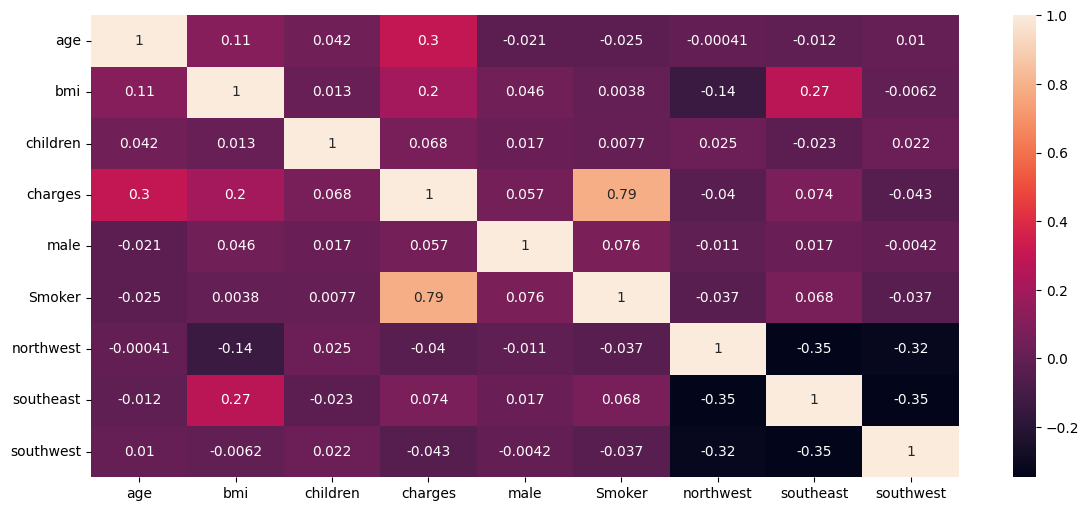

In [19]:
plt.figure(figsize=(14,6))
sns.heatmap(df.corr(),annot=True)

In [20]:
df.corr()

,age,bmi,children,charges,male,Smoker,northwest,southeast,southwest
age,1.000000,0.109272,0.042469,0.299008,-0.020856,-0.025019,-0.000407,-0.011642,0.010016
bmi,0.109272,1.000000,0.012759,0.198341,0.046371,0.003750,-0.135996,0.270025,-0.006205
children,0.042469,0.012759,1.000000,0.067998,0.017163,0.007673,0.024806,-0.023066,0.021914
charges,0.299008,0.198341,0.067998,1.000000,0.057292,0.787251,-0.039905,0.073982,-0.043210
male,-0.020856,0.046371,0.017163,0.057292,1.000000,0.076185,-0.011156,0.017117,-0.004184
Smoker,-0.025019,0.003750,0.007673,0.787251,0.076185,1.000000,-0.036945,0.068498,-0.036945
northwest,-0.000407,-0.135996,0.024806,-0.039905,-0.011156,-0.036945,1.000000,-0.346265,-0.320829
southeast,-0.011642,0.270025,-0.023066,0.073982,0.017117,0.068498,-0.346265,1.000000,-0.346265
southwest,0.010016,-0.006205,0.021914,-0.043210,-0.004184,-0.036945,-0.320829,-0.346265,1.000000


## Splitting the Data

In [21]:
x = df.drop('charges',axis=1)
y = df['charges']

In [22]:
x.head()

,age,bmi,children,male,Smoker,northwest,southeast,southwest
0,19,27.900,0,0,1,0,0,1
1,18,33.770,1,1,0,0,1,0
2,28,33.000,3,1,0,0,1,0
3,33,22.705,0,1,0,1,0,0
4,32,28.880,0,1,0,1,0,0


In [23]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.4)

In [25]:
x_train.shape

(802, 8)

In [27]:
x_test.shape

(536, 8)

## Scaling Data

In [29]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [30]:
scaled_x_train = scaler.fit_transform(x_train)
scaled_x_test = scaler.transform(x_test)

In [32]:
x_train

,age,bmi,children,male,Smoker,northwest,southeast,southwest
231,59,27.830,3,0,0,0,1,0
1067,39,42.655,0,1,0,0,0,0
1322,62,38.830,0,1,0,0,1,0
510,56,32.110,1,1,0,0,0,0
654,59,35.200,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...
12,23,34.400,0,1,0,0,0,1
971,34,23.560,0,0,0,0,0,0
463,56,25.935,0,1,0,0,0,0
1128,34,32.800,1,1,0,0,0,1


In [31]:
scaled_x_train

array([[ 1.35714072, -0.4513608 ,  1.58822163, ..., -0.59175024,
         1.68990214, -0.56871112],
       [-0.07180356,  1.98910994, -0.89957866, ..., -0.59175024,
        -0.59175024, -0.56871112],
       [ 1.57148236,  1.35944379, -0.89957866, ..., -0.59175024,
         1.68990214, -0.56871112],
       ...,
       [ 1.14279908, -0.76331305, -0.89957866, ..., -0.59175024,
        -0.59175024, -0.56871112],
       [-0.42903963,  0.36679364, -0.07031189, ..., -0.59175024,
        -0.59175024,  1.75836195],
       [ 0.99990465,  0.2186369 , -0.07031189, ..., -0.59175024,
         1.68990214, -0.56871112]])

## Support Vector Regression

In [33]:
from sklearn.svm import SVR

In [34]:
regressor = SVR(kernel='rbf')
regressor.fit(scaled_x_train, y_train)

SVR()

In [35]:
predict = regressor.predict(scaled_x_test)

In [36]:
predict

array([9296.29688128, 9321.40845515, 9310.53449873, 9298.18682284,
       9274.87012322, 9300.34794399, 9294.32895128, 9304.14908685,
       9328.12879889, 9323.89989326, 9292.48902475, 9326.2778497 ,
       9281.70819515, 9349.68251038, 9327.4606046 , 9332.75182381,
       9280.75609252, 9329.92798523, 9292.4108913 , 9331.15808251,
       9314.45110426, 9275.73172929, 9258.22165722, 9342.5634237 ,
       9267.00164198, 9335.36552649, 9322.39559802, 9322.72263498,
       9265.55675725, 9320.79414669, 9328.64169383, 9281.93981435,
       9290.58342618, 9314.31808447, 9309.25287376, 9307.27657756,
       9294.42508578, 9326.49792587, 9275.71361526, 9266.2834242 ,
       9280.69625398, 9350.84580111, 9323.037442  , 9330.60178828,
       9310.53787712, 9261.70403647, 9309.17183876, 9309.02989311,
       9344.24694671, 9281.82088918, 9340.62791988, 9340.05167383,
       9328.00410385, 9348.26337532, 9326.41886297, 9288.00440616,
       9265.70290882, 9294.96094559, 9263.55858727, 9351.71022

In [37]:
y_test

1234     8515.75870
105     17560.37975
425      9788.86590
688     26236.57997
1316     1731.67700
           ...     
1266    10704.47000
56      13607.36875
833     11743.93410
571      2219.44510
501      6837.36870
Name: charges, Length: 536, dtype: float64

In [38]:
np.mean((y_test - predict)**2)

154970368.72622922

Text(0.5, 0, 'Predict')

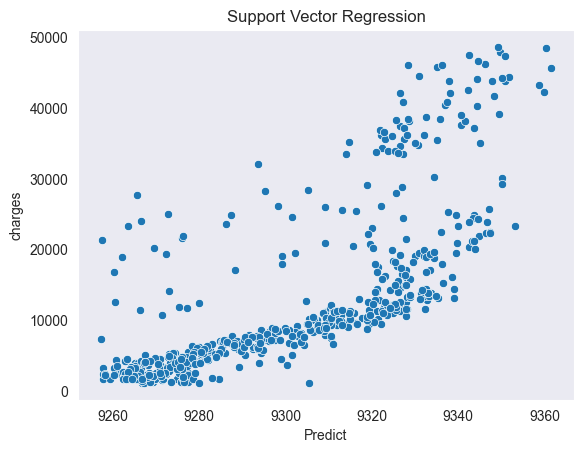

In [42]:
sns.set_style('dark')
f = sns.scatterplot(x = predict,y = y_test)
f.set_title('Support Vector Regression')
f.set_xlabel('Predict')
# Text(0.5, 0, 'Predict')